### KMeans example 2, weather conditions

In [51]:
# importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import the KMeans algorithm
from sklearn.cluster import KMeans

In [52]:
# load the dataset
df = pd.read_csv("data_pertanian_modern_fake.csv")

In [53]:
df.head()

,humidity,temperature,windspeed,precipitation,solar irradiance
0,2.961072,1.506010,2.533052,-2.156108,-0.476586
1,2.809125,0.956902,1.950795,0.269170,0.709486
2,2.711679,2.229877,2.329416,2.715768,-1.407908
3,1.524003,2.487360,1.865546,2.365030,-0.590172
4,0.460455,2.786802,1.430119,2.659718,-0.525686


In [54]:
# let's only select two variables so we can easily visualize the result
df = df[['windspeed', 'precipitation']]

In [55]:
df

,windspeed,precipitation
0,2.533052,-2.156108
1,1.950795,0.269170
2,2.329416,2.715768
3,1.865546,2.365030
4,1.430119,2.659718
...,...,...
495,1.968867,0.479957
496,1.721002,-2.504269
497,-1.133713,0.911452
498,1.431071,-0.274127


C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_16020\3150355198.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="windspeed", y="precipitation", data=df, palette="tab10")


<Axes: xlabel='windspeed', ylabel='precipitation'>

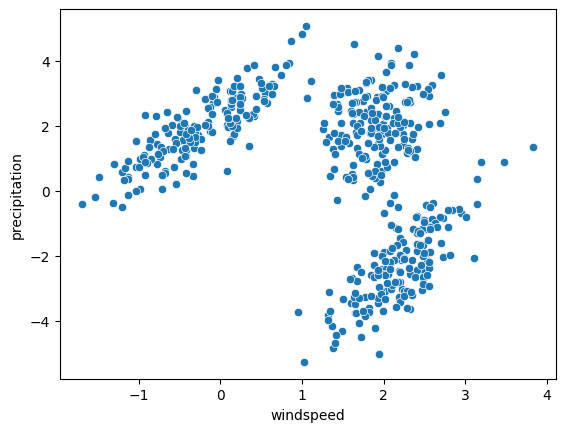

In [56]:
sns.scatterplot(x="windspeed", y="precipitation", data=df, palette="tab10")

In [57]:
X = df.values
X

array([[ 2.53305151, -2.1561083 ],
       [ 1.95079532,  0.26917   ],
       [ 2.32941588,  2.71576775],
       [ 1.86554562,  2.36503022],
       [ 1.43011909,  2.6597182 ],
       [ 2.09709042,  3.92523314],
       [ 1.97772289,  1.12483329],
       [-0.78029081,  1.4269205 ],
       [ 1.79759922,  2.92057238],
       [ 2.5336448 , -2.33045966],
       [ 1.35006741,  0.46222465],
       [-1.19848188, -0.48946132],
       [ 0.20541072,  2.86189201],
       [ 2.51730462, -1.18146322],
       [-0.14612485,  2.10963919],
       [ 1.98245092,  1.74832567],
       [ 2.23456166,  1.4074556 ],
       [ 1.77924846,  2.42804804],
       [ 2.36462978, -1.16685022],
       [ 1.67661803,  1.32471104],
       [ 3.14373964, -0.41640544],
       [ 0.20090652,  2.12823174],
       [-0.65569576,  2.41961965],
       [ 1.87727162, -1.90726084],
       [ 2.44562725, -1.63954261],
       [-0.46181743,  1.78826703],
       [ 1.89110503,  0.39099982],
       [ 2.15680876, -1.15485955],
       [ 1.02319359,

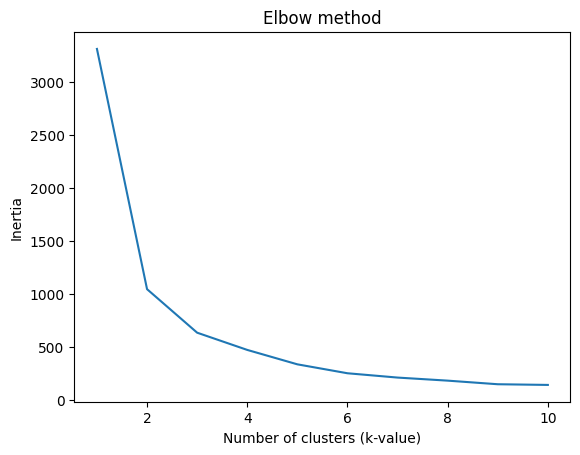

In [58]:
# let's use the elbow method
inertias = []

# using a for loop to iterate through clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# visualize the elbow
plt.plot(range(1, 11), inertias)
plt.title("Elbow method")
plt.xlabel('Number of clusters (k-value)')
plt.ylabel('Inertia')
plt.show()

### Let's use 3 clusters (even though 2-4 are probably all useful here)

In [59]:
# finally, train the actual KMEAN-algorithm
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
predictions = kmeans.fit_predict(X)

In [60]:
predictions

array([1, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 2, 2, 1, 2, 0, 0, 0, 1, 0, 1, 2,
       2, 1, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 2, 0, 2, 1,
       1, 1, 0, 0, 1, 1, 2, 1, 0, 1, 0, 2, 0, 2, 2, 0, 2, 1, 1, 0, 2, 1,
       1, 0, 2, 2, 0, 0, 2, 0, 1, 2, 2, 2, 2, 2, 1, 0, 1, 1, 1, 0, 0, 2,
       2, 1, 1, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 0, 2, 2, 2, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1, 0, 0, 0, 0, 1, 2, 2, 0, 1, 2,
       0, 1, 1, 0, 0, 0, 0, 2, 2, 2, 1, 1, 1, 0, 2, 0, 2, 2, 1, 2, 2, 1,
       2, 1, 2, 2, 1, 0, 0, 2, 0, 1, 0, 0, 2, 1, 2, 1, 2, 2, 2, 2, 0, 0,
       1, 1, 1, 0, 2, 2, 1, 0, 0, 2, 0, 2, 0, 0, 0, 2, 1, 2, 2, 2, 0, 1,
       1, 1, 1, 2, 0, 0, 2, 1, 2, 1, 0, 1, 0, 0, 0, 2, 1, 2, 0, 1, 1, 2,
       1, 2, 1, 1, 0, 2, 2, 1, 0, 0, 0, 0, 2, 0, 1, 2, 0, 1, 1, 2, 1, 2,
       2, 0, 0, 2, 0, 0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2,
       1, 2, 2, 1, 2, 1, 1, 1, 2, 0, 2, 1, 1, 0, 1,

In [61]:
# let's attach the clusters back to original data
df['CLUSTER'] = predictions

In [62]:
df.sample(10)

,windspeed,precipitation,CLUSTER
376,0.236846,2.869262,2
260,2.049996,-2.815204,1
274,2.002603,-0.667820,1
316,-0.451557,1.210763,2
410,1.929768,-2.421132,1
427,2.488350,-1.988941,1
460,1.984585,3.177500,0
453,1.481557,3.158160,0
52,2.174992,4.394355,0
414,-0.333586,0.838390,2


<Axes: xlabel='windspeed', ylabel='precipitation'>

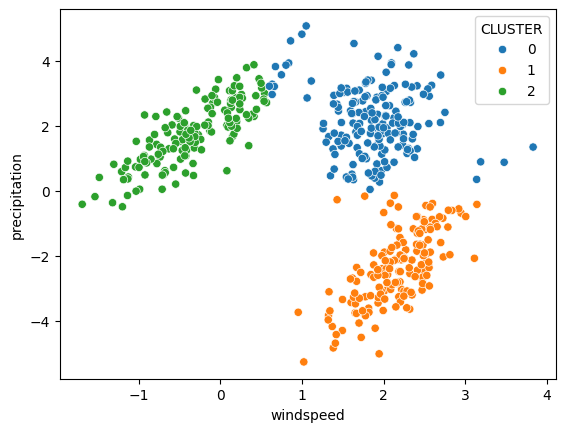

In [63]:
sns.scatterplot(x="windspeed", y="precipitation", hue="CLUSTER", data=df, palette="tab10")

In [64]:
df.groupby(['CLUSTER']).mean()[['windspeed', 'precipitation']]

,windspeed,precipitation
CLUSTER,,
0,1.867483,2.165241
1,2.162180,-2.333374
2,-0.329120,1.768850


### Based on these averages, it seems we have four groups of customers:

In [ ]:
# Cluster 0 = High wind, High precipitation
# Cluster 1 = High wind, Low precipitation
# Cluster 2 = Low wind, High precipitation 


In [66]:
df['CLUSTER'].value_counts()

CLUSTER
0    179
1    168
2    153
Name: count, dtype: int64